In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from knapsack_solver import KnapsackSolver
import seaborn as sns
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")

In [10]:
# FILENAMES = {
#     8: os.path.join('data','rouge_scores_ULS','ULS_3.0x_rouge_scores_29-07_18-17-27.csv'),
#     13: os.path.join('data','rouge_scores_ULS','ULS_1.85x_rouge_scores_29-07_17-48-23.csv'),
#     16: os.path.join('data','rouge_scores_ULS','ULS_1.5x_rouge_scores_29-07_17-28-33.csv'),
#     24: os.path.join('data','rouge_scores_ULS','ULS_1.0x_rouge_scores_29-07_18-00.csv')
#     }
FILENAMES = {
    8: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_3.0x_rouge_scores_05-08_14-15-32.csv'),
    13: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_1.85x_rouge_scores_05-08_14-09-41.csv'),
    16: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_1.5x_rouge_scores_05-08_14-03-55.csv'),
    24: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_1.0x_rouge_scores_05-08_13-58-14.csv')
    }



In [11]:
df_dict = {
    k: pd.read_csv(v) for k, v in FILENAMES.items()
}

In [12]:
print(df_dict[8]["rougeL"][10:20]) #24
print(df_dict[13]["rougeL"][10:20]) #16
print(df_dict[16]["rougeL"][10:20]) #13
print(df_dict[24]["rougeL"][10:20]) #8



10    0.380952
11    0.173913
12    0.235294
13    0.530612
14    0.555556
15    0.193548
16    0.350000
17    0.339623
18    0.400000
19    0.129032
Name: rougeL, dtype: float64
10    0.380952
11    0.583333
12    0.380952
13    0.313725
14    0.555556
15    0.258065
16    0.486486
17    0.509091
18    0.320000
19    0.142857
Name: rougeL, dtype: float64
10    0.285714
11    0.666667
12    0.384615
13    0.384615
14    0.555556
15    0.145455
16    0.700000
17    0.521739
18    0.275862
19    0.333333
Name: rougeL, dtype: float64
10    0.285714
11    0.583333
12    0.454545
13    0.391304
14    0.235294
15    0.190476
16    0.458333
17    0.458333
18    0.307692
19    0.076923
Name: rougeL, dtype: float64


In [13]:
values = np.vstack([df['rougeL'].values for df in df_dict.values()]).T
weights = np.vstack([[k]*len(df) for k, df in df_dict.items()]).T

print(values[:5])
print(weights[:5])
print(values.shape)
print(weights.shape)


[[0.44444444 0.33333333 0.375      0.4       ]
 [0.15686275 0.28571429 0.24137931 0.25396825]
 [0.56521739 0.25       0.26666667 0.37209302]
 [0.44444444 0.34482759 0.46666667 0.58823529]
 [0.45714286 0.55555556 0.4        0.35294118]]
[[ 8 13 16 24]
 [ 8 13 16 24]
 [ 8 13 16 24]
 [ 8 13 16 24]
 [ 8 13 16 24]]
(818, 4)
(818, 4)


In [14]:
#sort each row by value, and apply the same permutation to weights
sort_perm = np.argsort(-values, axis=1)
values_sorted = np.take_along_axis(values, sort_perm, axis=1)
weights_sorted = np.take_along_axis(weights, sort_perm, axis=1)





In [15]:
print(values_sorted[:5])
print(weights_sorted[:5])

[[0.44444444 0.4        0.375      0.33333333]
 [0.28571429 0.25396825 0.24137931 0.15686275]
 [0.56521739 0.37209302 0.26666667 0.25      ]
 [0.58823529 0.46666667 0.44444444 0.34482759]
 [0.55555556 0.45714286 0.4        0.35294118]]
[[ 8 24 16 13]
 [13 24 16  8]
 [ 8 24 16 13]
 [24 16  8 13]
 [13  8 16 24]]


In [16]:
#KNAPSACK!
max_capacity = values.shape[0] * 24

kp_solver = KnapsackSolver(values_sorted, weights_sorted, shard_number=2)

kp_solver.solve()

In [17]:
optimal_rouges = np.array([kp_solver.get_optimal_value(c) for c in range(max_capacity+1)])

In [18]:
#find last occurence of -np.inf
last_inf = np.where(optimal_rouges == -np.inf)[0][-1] 

In [19]:
optimal_rouges_clean = optimal_rouges[last_inf+1:]

In [20]:
optimal_rouges_final = optimal_rouges_clean / values.shape[0]
print(optimal_rouges_final)

[0.38251199 0.38251199 0.38251199 ... 0.48638224 0.48638224 0.48638224]


In [21]:
#average rouge scores for each df in df_dict
ULS_constant_rouges = [df['rougeL'].mean() for df in df_dict.values()]
ULS_layer_use = [k for k in df_dict.keys()]

optimal_rouge_layer_use = np.arange(last_inf+1, last_inf+1+len(optimal_rouges_final)) / values.shape[0]

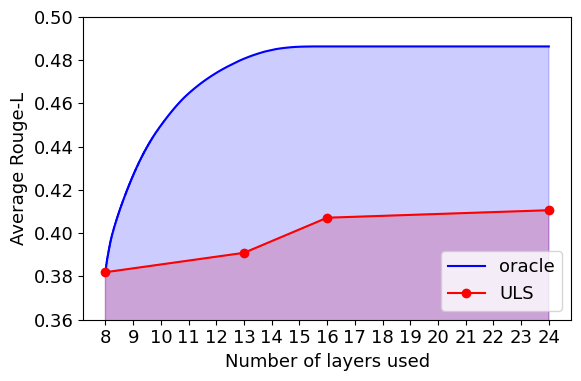

In [22]:
plt.figure(figsize=(6,4))
#font size
plt.rc('font', size=13)
plt.plot(optimal_rouge_layer_use, optimal_rouges_final, label='oracle', color='blue')
#scatter with line connecting points
plt.plot(ULS_layer_use, ULS_constant_rouges, label='ULS', color='red', marker='o')
#compare AUC
plt.fill_between(ULS_layer_use, ULS_constant_rouges, alpha=0.2, color='red')
plt.fill_between(optimal_rouge_layer_use, optimal_rouges_final, alpha=0.2, color='blue')
plt.xlabel('Number of layers used')
plt.ylabel('Average Rouge-L')
#change y range
plt.ylim(0.36, 0.50)
plt.legend(loc='lower right', fontsize=13)
plt.xticks(np.arange(8, 25, 1))
plt.tight_layout()
#plt.savefig(r'data\rouge_scores_ULS\SAMSUM_oracle_vs_ULS.png')
plt.show()
#why is savefig showing a blank image?
#A: 





In [23]:
#save optimal_rouges
#np.save(r'data\rouge_scores_ULS\oracle_rouges.npy', optimal_rouges)

In [24]:
average_layers = [8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
choices_for_layer = [kp_solver.reconstruct_chosen_items(layer*values.shape[0]) for layer in average_layers]
occurences_model = [[0,0,0,0] for _ in range(len(choices_for_layer))]
for i in range(len(choices_for_layer)):
    occurences_model[i][0] += choices_for_layer[i].count(8) / float(values.shape[0])
    occurences_model[i][1] += choices_for_layer[i].count(13) / float(values.shape[0])
    occurences_model[i][2] += choices_for_layer[i].count(16) / float(values.shape[0])
    occurences_model[i][3] += choices_for_layer[i].count(24) / float(values.shape[0])


In [25]:
#calculate budget actually used
budget_used = [sum([8,13,16,24][i]/24.0 * occurences_model[j][i] for i in range(4)) for j in range(len(average_layers))]

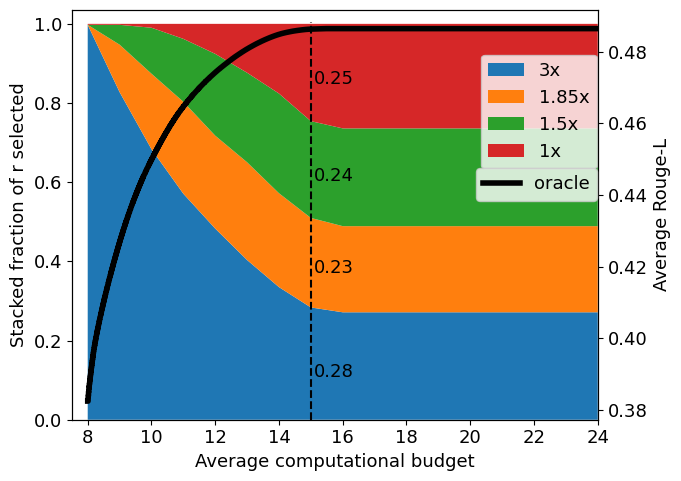

In [26]:
#defuat style
plt.style.use('default')
plt.rc('font', size=13)
plt.figure(figsize=(7,5))
# plot as stacked line chart,
occurences_model = np.array(occurences_model)
plt.stackplot(average_layers, occurences_model.T, labels=['3x', '1.85x', '1.5x', '1x'])
#plt.plot(np.arange(8,25,1), budget_used, color='purple', linewidth=2)
plt.legend(loc=(0.778,0.614))
plt.xlabel('Average computational budget')
plt.ylabel('Stacked fraction of r selected')

#add vertical dashed line at 15
plt.axvline(x=15, color='black', linestyle='--',ymax=0.97)
#add text of values of occurences_model at 12
for i, txt in enumerate(occurences_model[7]):
    plt.text(15.1, sum(occurences_model[7,:i]) + 0.38*occurences_model[7,i], str(round(txt,2)), color='black')
# for i, txt in enumerate(occurences_model[4]):
#     plt.text(11.1, sum(occurences_model[4,:i]) + 0.38*occurences_model[4,i], str(round(txt,2)), color='black')
plt.grid(False)
plt.ylim(0,1.035)
#add rouge socre on secondary y axis
plt.twinx()
plt.ylabel('Average Rouge-L')
#plt.ylim(0.277, 0.360)
#plt.ylim(0.37, 0.447)
plt.plot(optimal_rouge_layer_use, optimal_rouges_final, label='oracle', color='black',linewidth=4)
plt.legend(loc=(0.769,0.535))
#hide grid 
plt.grid(False)
plt.xlim(7.5,24)
plt.tight_layout()
#plt.savefig(r'data\rouge_scores_ULS\SAMSUM_oracle_stacked.png')
plt.show()

In [19]:
for i in range(len(average_layers)):
    print(f'Layer {average_layers[i]}: {optimal_rouges_final[np.where(average_layers[i] == optimal_rouge_layer_use)[0][0]]}')

Layer 8: 0.38251198766284
Layer 9: 0.4268143520961472
Layer 10: 0.4498401445981051
Layer 11: 0.4646435203645515
Layer 12: 0.4741505480628725
Layer 13: 0.48071221908905104
Layer 14: 0.4847772127258749
Layer 15: 0.48625198028489836
Layer 16: 0.4863822396052204
Layer 17: 0.4863822396052204
Layer 18: 0.4863822396052204
Layer 19: 0.4863822396052204
Layer 20: 0.4863822396052204
Layer 21: 0.4863822396052204
Layer 22: 0.4863822396052204
Layer 23: 0.4863822396052204
Layer 24: 0.4863822396052204


In [22]:
print(np.mean(df_dict[16]['rougeL']))

0.4071759223151636


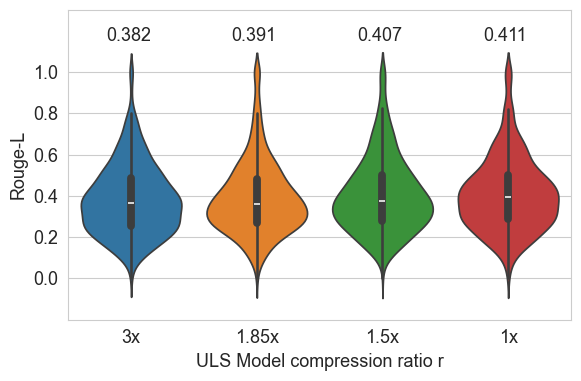

In [26]:
#set style seaborn
sns.set_style('whitegrid')
#violin plots of rouge scores, colorful
plt.figure(figsize=(6,4))
violin_data = {
    '3x': df_dict[8]['rougeL'],
    '1.85x': df_dict[13]['rougeL'],
    '1.5x': df_dict[16]['rougeL'],
    '1x': df_dict[24]['rougeL']
}
sns.violinplot(data=violin_data)
#show average rouge scores
for i, (k, v) in enumerate(violin_data.items()):
    plt.text(i, v.mean(), f'{v.mean():.3f}', position=(i-0.2,1.15))
plt.xticks(np.arange(4), ['3x', '1.85x', '1.5x', '1x'])
plt.ylim(-0.2, 1.3)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylabel('Rouge-L')
plt.xlabel('ULS Model compression ratio r')
plt.tight_layout()
plt.savefig(r'data\rouge_scores_ULS\SAMSUM_ULS_rouge_violin.png')
plt.show()

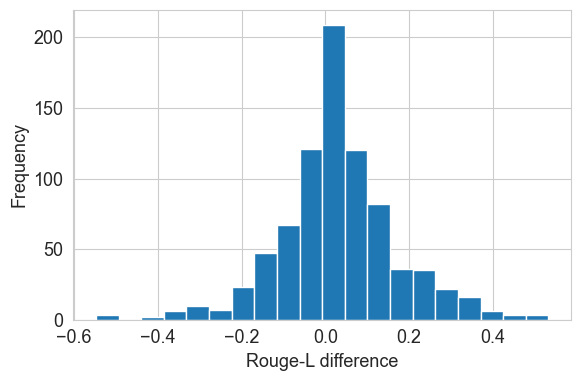

In [27]:
#Look at rouge score difference between 1.0x and 3.0x, and plot as histogram
plt.figure(figsize=(6,4))
plt.hist(df_dict[24]['rougeL'] - df_dict[8]['rougeL'], bins=20)
plt.xlabel('Rouge-L difference')
plt.ylabel('Frequency')
plt.tight_layout()


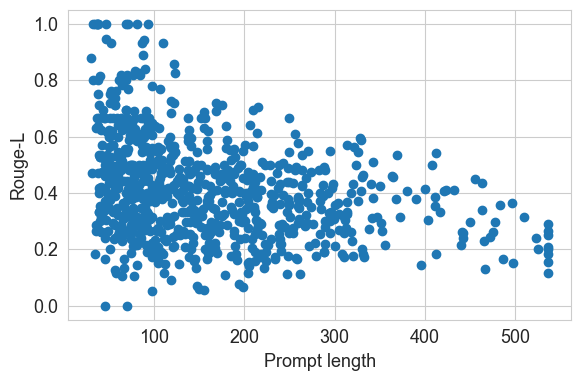

In [28]:
#PLot prompt lenghts against rouge score for 1.0x 
plt.figure(figsize=(6,4))
plt.scatter(df_dict[24]['prompt_length'], df_dict[24]['rougeL'])
plt.xlabel('Prompt length')
plt.ylabel('Rouge-L')
plt.tight_layout()


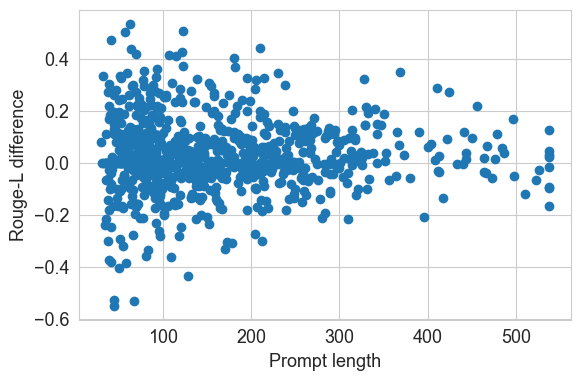

In [29]:
#PLot prompt lenghts against rouge score diffrence for 1.0x and 3.0x
plt.figure(figsize=(6,4))
plt.scatter(df_dict[24]['prompt_length'], df_dict[24]['rougeL'] - df_dict[8]['rougeL'])
plt.xlabel('Prompt length')
plt.ylabel('Rouge-L difference')
plt.tight_layout()


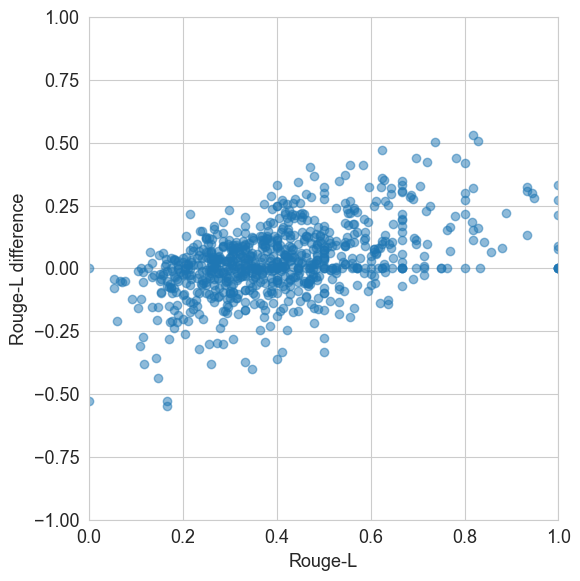

In [30]:
#Plot rouge score of 1.0x against rouge score diffrence for 1.0x and 3.0x
plt.figure(figsize=(6,6))
plt.scatter(df_dict[24]['rougeL'], df_dict[24]['rougeL'] - df_dict[8]['rougeL'],alpha=0.5)
plt.xlim(0.0,1.0)
plt.ylim(-1.0,1.0)
plt.xlabel('Rouge-L')
plt.ylabel('Rouge-L difference')
plt.tight_layout()

C:\Users\thgla\AppData\Local\Temp\ipykernel_14588\1229896256.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


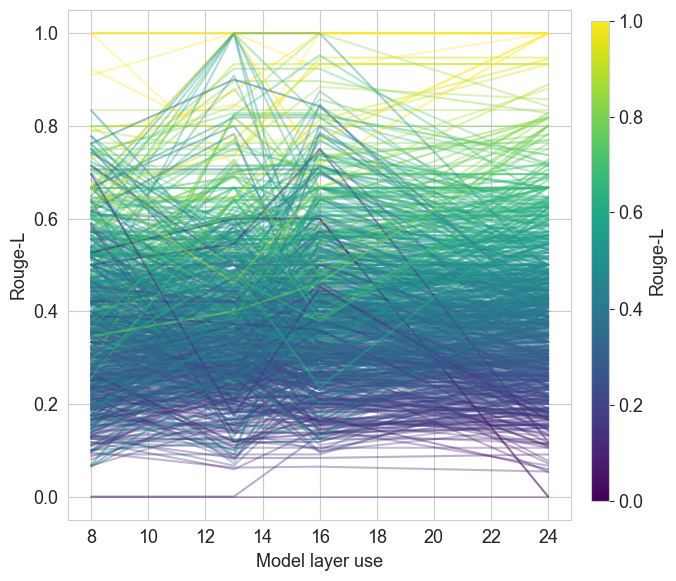

In [32]:
#plot the rouge score for 3.0x,1.85x,1.5x,1.0x of each prompt as a seperate series, with a unique color based on the ROUGe score of the 1.0x model. change transparency based on rouge change
plt.figure(figsize=(6,6))
colors = df_dict[24]['rougeL']
for i in range(len(df_dict[24])):
    plt.plot([8,13,16,24], [df_dict[8]['rougeL'][i], df_dict[13]['rougeL'][i], df_dict[16]['rougeL'][i], df_dict[24]['rougeL'][i]], color=plt.cm.viridis(colors[i]), alpha=0.3+abs(df_dict[24]['rougeL'][i] - df_dict[8]['rougeL'][i])/2)
plt.xlabel('Model layer use')
plt.ylabel('Rouge-L')
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Rouge-L',cax=plt.axes([1.0, 0.15, 0.03, 0.8]))
plt.tight_layout()


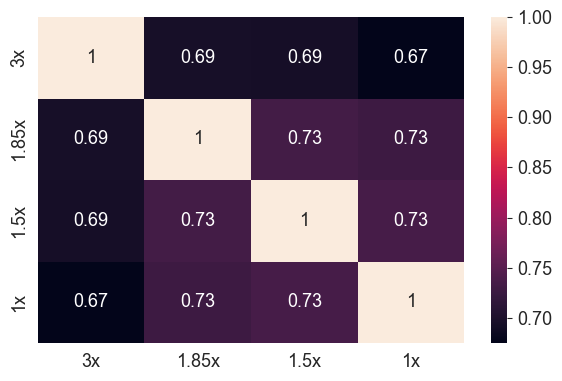

In [33]:
#correlation matrix of rouge scores only
plt.figure(figsize=(6,4))
rouge_mat = pd.concat([df['rougeL'] for df in df_dict.values()], axis=1)
#rename columns
rouge_mat.columns = ['3x', '1.85x', '1.5x', '1x']
    
sns.heatmap(rouge_mat.corr(), annot=True)
plt.tight_layout()


In [1]:
import torch

c:\Users\thgla\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
input = torch.tensor([0.1, 1.0])
ones = 0
zeros = 0
for i in range(1000):
    output = torch.nn.functional.gumbel_softmax(input, tau=0.1, hard=True)
    ones += output[1]
    zeros += output[0]
print(f'ones: {ones/1000}, zeros: {zeros/1000}')

ones: 0.7099999785423279, zeros: 0.28999999165534973


In [13]:
empty_like = torch.empty_like(input, memory_format=torch.legacy_contiguous_format)
exp = empty_like.exponential_()
gumbels = -exp.log()
print(gumbels)

tensor([0.6263, 1.2229])
